# Notebook for constructing age models for the Portage Lake Volcanics age model

In [4]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Portage Lake Volcanics

- modified from Cannon and Nicholson 2001
- The bottom of the strat is bounded by the Keweenaw fault, we assign a minimum age of 1098 Ma based on the estimated younger side of the known beginning of the normal superchron
- The minimum age bound for the strat bottom is also the date of the Copper City Flow. 
- Greenstone Flows serves as a bound in the middle of the strat
- The top of the strat is bounded by the Nonesuch Formation which has a Re-Os age of 1078 Ma. 

In [5]:
PLV_Name =          ("Keweenaw Fault", "Copper City Flow base", "Copper City Flow", "Greenstone Flow", "Lake Shore Traps", "base of Nonesuch Shale") # Et cetera
PLV_Age           = [1098,              1093.37,                 1093.37,            1091.59,           1085.57,            1078] # Measured ages
PLV_Age_sigma     = [0,                 0.53/2,                  0.53/2,             0.27/2,            0.25/2,             24/2] # Measured 1-σ uncertainties
PLV_Height        = [0,                 0,                       1000,               3558,              5505,               6055] # Depths below surface should be negative
PLV_Age_Sidedness = [1,                 1,                      0,                  0,                 0,                  0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

PLV_Path = "../../data/age_models_output/PLV" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
PLV_section = make_ChronAgeData(PLV_Name, PLV_Age, PLV_Age_sigma, PLV_Height, PLV_Age_Sidedness, PLV_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{6}(("Keweenaw Fault", "Copper City Flow base", "Copper City Flow", "Greenstone Flow", "Lake Shore Traps", "base of Nonesuch Shale"), [0.0, 0.0, 1000.0, 3558.0, 5505.0, 6055.0], [0.01, 0.01, 0.01, 0.01, 0.01, 0.01], [1098.0, 1093.37, 1093.37, 1091.59, 1085.57, 1078.0], [0.0, 0.265, 0.265, 0.135, 0.125, 12.0], [NaN, NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN, NaN], [1.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../../data/age_models_output/PLV", 2, "Ma", "m", :cdf)

In [6]:
PLV_age_model_config, PLV_age_model_mdl, PLV_age_model_agedist, PLV_age_model_lldist = run_age_model(PLV_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 848000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 848000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 848000, 1000, 848, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  5960.0, 5970.0, 5980.0, 5990.0, 6000.0, 6010.0, 6020.0, 6030.0, 6040.0, 6050.0], [1099.422021121567, 1099.3765647196735, 1099.3098931119719, 1099.2479202724803, 1099.1856912031758, 1099.1167016077113, 1099.058809661656, 1098.9922425920124, 1098.935360431228, 1098.8876734745304  …  1082.0464864328787, 1081.9808658231163, 1081.9190350807391, 1081.8428423578075, 1081.7710556468462, 1081.701010051623, 1081.6611520573542, 1081.5659160858766, 1081.5042535704958, 1081.4522014987035], [1.0998971622121347, 1.1677653249271323, 1.2341360343591576, 1.304469302900843, 1.3414391739586522, 1.395131158911088, 1.4138090667244851, 1.4700428480946643, 1.4996624489407748, 1.5142005180775637  …  2.2358616898043473, 2.2405775119758116, 2.25583758630029, 2.2967553368688596, 2.3261499385730784, 2.3428429933193313, 2.3491588854503167, 2.383781852387065, 2.387454446612797, 2.39

### posterior summary age model

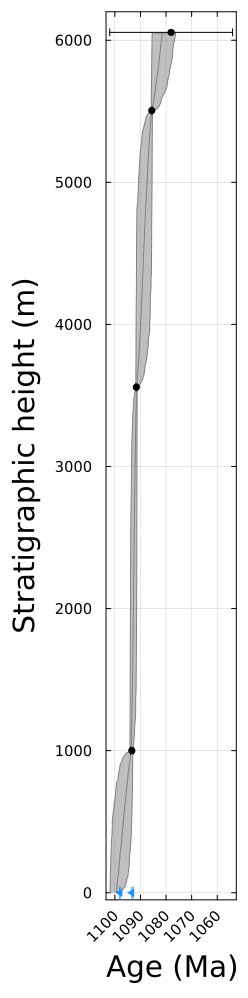

In [10]:
PLV_age_model = plot_age_model(PLV_section, PLV_age_model_mdl, save_figure=false)
plot!(ylim=(-50, 6200), size=(250, 1000), legendfontsize=8)
# add left padding
plot!(left_margin = 12Plots.mm, guidefontsize=20, legend=false)
savefig(PLV_age_model, PLV_section.Path*"_AgeDepthModel.pdf")
display(PLV_age_model)

### example posterior accumulation models

agemin: 1081.4550749515172, agemax: 1099.4749780472982, halfw: 1.0, Δt: 0.4
Number of windows: 41
  0.147233 seconds (9.00 k allocations: 14.832 MiB, 76.12% gc time)


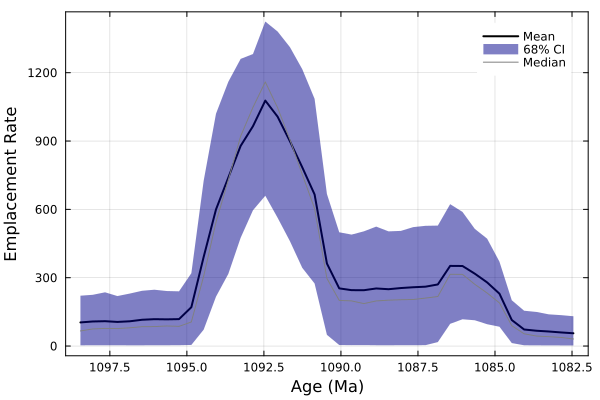

In [11]:
plot_accumulation_model(PLV_section, PLV_age_model_config, PLV_age_model_mdl, PLV_age_model_agedist,  binwidth=2, stepfrac=0.2, save_figure=false)

### example posterior age models

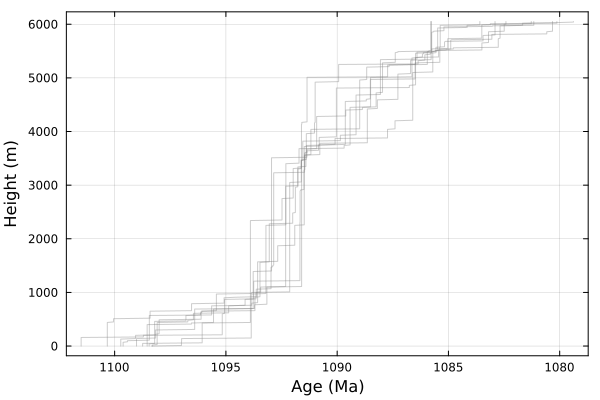

In [7]:
plot_posterior_paths(PLV_section, PLV_age_model_agedist, PLV_age_model_mdl)

## save the age models to a file

In [8]:
PLV_age_model_agedist

606×1000 Matrix{Float64}:
 1100.31  1100.78  1101.34  1099.31  …  1101.71  1099.72  1099.88  1100.04
 1100.31  1100.78  1101.34  1099.31     1101.71  1099.72  1099.88  1097.97
 1100.31  1100.78  1101.34  1099.31     1101.71  1099.72  1099.88  1097.97
 1100.31  1100.78  1101.34  1099.31     1101.71  1099.72  1099.88  1097.97
 1100.31  1100.78  1101.34  1099.31     1101.71  1099.72  1099.88  1097.97
 1100.31  1100.78  1101.34  1099.31  …  1101.71  1099.72  1099.88  1097.15
 1100.31  1100.78  1100.39  1099.31     1101.71  1099.72  1099.88  1097.15
 1100.31  1100.78  1100.39  1099.31     1101.71  1099.72  1099.88  1097.15
 1100.31  1100.78  1100.39  1099.31     1101.71  1099.72  1099.88  1097.15
 1100.31  1100.78  1100.39  1099.31     1101.71  1099.72  1099.88  1097.15
    ⋮                                ⋱                             
 1083.51  1085.72  1080.45  1084.67     1080.17  1082.49  1083.96  1082.78
 1083.51  1085.72  1080.45  1084.67     1080.17  1082.49  1083.96  1082.78
 1083.

In [9]:
# use the mdl.height as index, agedist as the data
PLV_age_models_df = DataFrame(hcat(PLV_age_model_mdl.Height, PLV_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(PLV_age_models_df, Dict(:x1 => "height"))
PLV_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1100.31,1100.78,1101.34,1099.31,1099.23,1101.23,1100.36,1098.83,1100.12,1099.97,1100.95,1099.4,1099.28,1100.04,1099.77,1099.39,1099.94,1099.5,1099.48,1101.06,1100.92,1098.08,1098.03,1099.89,1098.56,1098.47,1100.48,1100.36,1100.48,1098.29,1099.91,1099.52,1102.08,1099.23,1101.79,1100.41,1100.21,1099.73,1100.46,1098.97,1099.25,1098.19,1099.91,1101.39,1100.2,1100.93,1099.55,1098.42,1102.27,1098.67,1098.15,1101.61,1100.31,1100.14,1100.24,1100.99,1100.04,1098.21,1099.52,1099.13,1101.12,1098.04,1098.65,1099.4,1099.6,1100.87,1098.5,1099.54,1101.53,1098.95,1098.42,1098.62,1100.26,1098.49,1098.54,1099.15,1100.52,1099.98,1098.3,1098.37,1100.69,1099.72,1101.1,1098.39,1099.7,1098.45,1098.25,1098.61,1098.65,1098.21,1098.3,1099.42,1100.45,1100.1,1099.98,1101.38,1098.34,1100.48,1099.0,⋯
2,10.0,1100.31,1100.78,1101.34,1099.31,1099.23,1101.23,1100.36,1098.83,1100.12,1099.97,1100.95,1099.4,1099.28,1100.04,1099.77,1099.39,1099.94,1099.5,1099.48,1101.06,1100.92,1098.08,1098.03,1099.89,1098.56,1098.47,1100.48,1100.36,1100.48,1098.29,1099.91,1099.52,1102.08,1099.23,1101.79,1100.41,1100.21,1099.73,1100.46,1098.97,1099.25,1098.19,1099.91,1101.39,1100.2,1100.93,1099.55,1098.42,1102.27,1098.67,1098.15,1101.61,1100.31,1100.14,1100.24,1100.99,1098.35,1098.21,1099.52,1099.13,1101.12,1097.68,1098.65,1099.4,1099.6,1100.87,1098.5,1099.54,1101.53,1098.95,1098.38,1098.62,1100.26,1098.49,1098.54,1099.15,1100.52,1099.98,1098.3,1098.37,1100.69,1099.72,1101.1,1098.39,1099.7,1098.45,1098.25,1098.61,1098.65,1098.21,1098.3,1099.42,1100.45,1100.1,1099.98,1101.38,1098.34,1100.48,1099.0,⋯
3,20.0,1100.31,1100.78,1101.34,1099.31,1099.23,1101.23,1100.36,1098.83,1100.12,1099.97,1100.95,1099.4,1099.28,1100.04,1099.77,1099.39,1099.94,1099.5,1099.48,1101.06,1100.92,1098.08,1098.03,1099.89,1098.56,1098.47,1100.48,1100.36,1098.05,1098.29,1099.91,1099.52,1099.66,1099.23,1101.79,1100.41,1100.21,1099.73,1100.46,1098.97,1099.25,1098.19,1099.91,1101.39,1100.2,1100.93,1099.55,1098.42,1102.27,1098.67,1097.51,1101.61,1100.31,1100.14,1100.24,1100.99,1098.35,1098.21,1099.52,1099.13,1101.12,1097.68,1098.65,1099.4,1099.6,1100.87,1098.5,1099.54,1101.53,1098.95,1098.38,1098.62,1100.26,1098.49,1098.54,1099.15,1100.52,1099.98,1098.3,1098.37,1100.69,1099.72,1098.73,1098.39,1099.7,1098.45,1098.25,1098.61,1098.65,1098.21,1098.3,1099.42,1100.45,1100.1,1099.98,1101.38,1098.14,1100.48,1099.0,⋯
4,30.0,1100.31,1100.78,1101.34,1099.31,1099.23,1101.23,1099.69,1098.83,1100.12,1099.97,1100.95,1099.4,1099.28,1100.04,1099.77,1099.39,1099.94,1096.19,1099.48,1101.06,1100.92,1098.08,1098.03,1099.89,1098.56,1098.47,1100.48,1100.36,1098.05,1098.29,1099.91,1099.52,1099.66,1099.23,1101.79,1100.41,1100.21,1099.73,1100.46,1098.97,1099.25,1098.19,1099.91,1101.39,1100.2,1100.93,1099.55,1098.42,1102.27,1098.67,1097.51,1101.61,1100.31

In [10]:
# write the DataFrame to a csv file
CSV.write(PLV_section.Path*"_posterior_ages.csv", PLV_age_models_df)

"../../data/age_models_output/PLV_posterior_ages.csv"